Option price at S0=100: 11.70164289555341
time taken: 9.99702769999567 seconds for 100000000 simulations


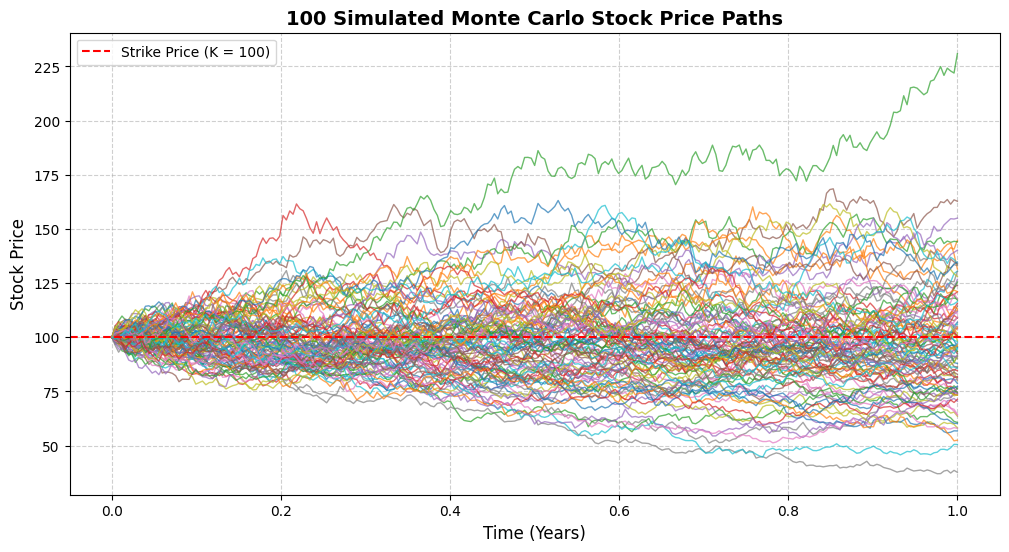

In [1]:
#basic monte carlo
import numpy as np
import time
import matplotlib.pyplot as plt  # Added missing import

sigma = 0.28879449806725843
r = 0.005
K = 100
T = 1  # years
S0 = 100
N = int(1e8)
M = 252 
dt = T / M
num_path_plots = 100


time_spaces = np.linspace(0, T, M + 1)

paths = np.zeros((M + 1, num_path_plots))
paths[0] = S0


for t in range(1, M + 1):
    z_path = np.random.randn(num_path_plots)
    paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z_path)


def monte_carlo_call_price(n_simulations=N):
    z = np.random.randn(n_simulations)
    s = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
    payoff = np.maximum(s - K, 0)
    return np.exp(-r*T) * np.mean(payoff)


start_time = time.perf_counter()
c = monte_carlo_call_price(N)
end_time = time.perf_counter()
time_taken = end_time - start_time

print("Option price at S0=100:", c)
print("time taken:", time_taken, "seconds for", N, "simulations")


plt.figure(figsize=(12, 6))
plt.plot(time_spaces, paths, linewidth=1, alpha=0.7)
plt.axhline(K, color='red', linestyle='--', label=f'Strike Price (K = {K})')

plt.title(f'{num_path_plots} Simulated Monte Carlo Stock Price Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [16]:
#stock volatility

import yfinance as yf
import numpy as np
import time
import subprocess
import matplotlib.pyplot as plt

data = yf.download("BP.L", period="5y")
close_prices = data["Close"].squeeze()
returns = np.log(close_prices / close_prices.shift(1))
sigma = returns.std() * np.sqrt(252)
r = 0.005
K = 100
T = 1  #years
S0 = 100
N = int(1e8)

start_time = time.perf_counter()

exe_path = r"C:\Users\mason\Projects\quant\monte carlo\ARM64\Release\monte carlo.exe"
result = subprocess.run( [exe_path, str(S0), str(K), str(r), str(sigma), str(T), str(N)], capture_output=True,text=True)


end_time = time.perf_counter()
time_taken = end_time - start_time


c = float(result.stdout.strip().split("=")[-1])
print("Option price at S=100:", c)
print("Calculated Volatility:" , sigma)
print("time taken:", time_taken, "seconds for", N, "simulations")





[*********************100%***********************]  1 of 1 completed


Option price at S=100: 11.7222
Calculated Volatility: 0.28923828430262993
time taken: 1.6656960000400431 seconds for 100000000 simulations
